In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


# Projeto 18: Compactação de imagens com Convolutional Autoencoders

Além de trabalhar com camadas lineares, trabalharemos com camadas convolucionais

## Etapa 1: Importação das bibliotecas

In [2]:
from torchvision import datasets, transforms
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
torch.__version__

'2.9.1+cpu'

In [3]:
# bibliotecas

In [4]:
# semente, gerar sempre o mesmo valor
torch.manual_seed(123)

## Etapa 2: Base de dados

In [5]:
# 1. Baixando e preparando o conjunto de dados (Dataset):
# 'MNIST-data_compacto': Nome da pasta onde as imagens serão salvas.
# train = True: Indica que queremos as 60.000 imagens de TREINO (não as de teste).
# download = True: Se os arquivos não estiverem na pasta, o PyTorch baixa da internet.
# transform = ToTensor(): Converte as imagens (que são arquivos de imagem comuns) 
# em Tensores (matrizes numéricas) e escala os pixels de 0-255 para 0-1.
dataset_train = datasets.MNIST('MNIST-data_compacto2', train = True, download = True,
                               transform = transforms.ToTensor())

# 2. Configurando o carregador de dados (DataLoader):
# dataset_train: A fonte dos dados que acabamos de definir.
# batch_size = 256: Em vez de entregar uma imagem por vez (muito lento) ou todas de 
# uma vez (pesado), ele entrega "pacotes" de 256 imagens por rodada.
# shuffle = True: Embaralha as imagens a cada época. Isso é vital para que a rede 
# não aprenda a "ordem" das imagens, mas sim o conteúdo delas.
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 256,
                                           shuffle = True)

In [6]:
# 1. Preparando o Conjunto de Validação (Teste):
# train = False: Este é o comando chave. Ele baixa as 10.000 imagens que NÃO 
# estão no conjunto de treino. O modelo nunca verá essas imagens durante o aprendizado.
# transform = transforms.ToTensor(): Garante que essas novas imagens tenham o mesmo 
# formato (0 a 1) e escala que as imagens de treino.
dataset_val = datasets.MNIST('MNIST-data_compacto2', train = False, download = True,
                             transform = transforms.ToTensor())

# 2. Configurando o Carregador de Validação:
# loader_val: Cria a esteira que entregará essas 10.000 imagens para teste.
# batch_size = 256: Mantemos o mesmo tamanho de pacote para manter a consistência.
# shuffle = True: Embora não seja obrigatório na validação (pois o modelo não está 
# aprendendo), embaralhar ajuda a ter uma visão imparcial do erro a cada lote.
loader_val = torch.utils.data.DataLoader(dataset_val, batch_size = 256,
                                         shuffle = True)

## Etapa 3: Construção do autoencoder

Antes trabalhavamos apenas com as redes neurais densas, agora vamos trabalhar com a camada Conv2d (convolucional) e também com a camada MaxPool2d.

In [7]:
class autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Camadas do encoder
        #3 camadas de convolução no encoder
        # --- ESTRUTURA DO ENCODER (Compressão Espacial) ---
        
        # enc0: Recebe 1 canal (Preto e Branco) e cria 16 mapas de características.
        # 16 canais ou filtros.
        # Usa um filtro 3x3 para detectar bordas simples.
        self.enc0 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=(3, 3))
        
        # enc1: Mantém 16 mapas e reduz para 8. O 'padding' evita que a imagem diminua aqui.
        # de 16 reduzimos para 8 canias ou filtros.
        self.enc1 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=(3, 3), padding=(1, 1))
        
        # enc2: Reduz a imagem usando 'stride=2'. É como se ele pulasse pixels para diminuir o tamanho.
        self.enc2 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))

        # maxpool: Reduzem a resolução pela metade, pegando apenas o pixel mais "forte" de cada região 2x2.
        # ir de 2 em 2 pixels. 
        self.maxpool0 = nn.MaxPool2d(kernel_size=(2, 2))
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2), padding=(1, 1))

        # Transforma os mapas 2D em um vetor único para o "gargalo" (espaço latente).
        self.flatten = nn.Flatten()
        
        # Camadas do decoder
        # já no decoder há 4 camadas de convolução
        # processo inverso
        # --- ESTRUTURA DO DECODER (Reconstrução Espacial) ---
        
        # dec0 a dec2: Pegam os mapas pequenos e começam a processar a volta.
        # replica apenas a última camada do encoder
        self.dec0 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=(3, 3), padding=(1, 1)) 
        self.dec1 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=(3, 3), padding=(1, 1))
        self.dec2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=(3, 3))
        
        # dec3: A camada final que reduz os 16 mapas de volta para apenas 1 canal (a imagem final).
        self.dec3 = nn.Conv2d(in_channels=16, out_channels=1, kernel_size=(3, 3), padding=(1, 1))
        
        # upsampling =>
        # como todo maxpooling era kernel_size = 2 (o que implica em fator de escalonamento = 0.5), 
        #agora eu posso usar o fator inverso, que é 2
        # upsampling, reduzimos a dimensionalidade e depois nós precisamos aumentar a dimensionalidade.     
        # upsampling: O oposto do pooling. Ele estica a imagem, dobrando o tamanho para voltar aos 28x28 originais.
        self.upsampling = nn.UpsamplingBilinear2d(scale_factor=2)
        
        # Camadas de ativação
        # Ativações: ReLU para as camadas internas e Sigmoid para garantir pixels entre 0 e 1 no final.
        self.activation0 = nn.ReLU() # Usada nas camadas internas para aprender padrões (usa nas camadas do meio)
        self.activation1 = nn.Sigmoid() # Usada na última camada para garantir pixels entre 0 e 1

    def forward(self, X):
        # --- FLUXO DO ENCODER ---
        X = self.maxpool0(self.activation0(self.enc0(X)))
        X = self.maxpool1(self.activation0(self.enc1(X)))
        X = self.flatten(self.activation0(self.enc2(X))) # Aqui X vira um vetor compacto
        
        # --- O PONTO DE VIRADA (RECONSTRUÇÃO) ---
        # Como o decoder usa Conv2d, precisamos "desachatar" o vetor de volta para um formato 3D (Canais, Altura, Largura).
        X = X.view(-1, 8, 4, 4)  # O número de canais (ou filtros) vai na segunda dimensão
        # parte do meio o h, batch =1 (de acordo com o treinamento), dimensão final no meio 8,4,4
        
        # --- FLUXO DO DECODER ---
        X = self.upsampling(self.activation0(self.dec0(X)))
        X = self.upsampling(self.activation0(self.dec1(X)))
        X = self.upsampling(self.activation0(self.dec2(X)))
        
        # Resultado final: a imagem reconstruída
        X = self.activation1(self.dec3(X)) # pelo sigmoid, entrega valores de 0 ou 1

        return X

In [8]:
# O Max Pooling funciona como um "filtro de relevância":
# 1. Ele desliza uma janela (ex: 2x2) sobre a imagem.
# 2. Em cada posição dessa janela, ele olha os 4 pixels e escolhe apenas o MAIOR valor.
# 3. Os outros 3 valores são descartados.

# No código: nn.MaxPool2d(kernel_size = (2, 2))
# Isso significa que a cada quadrado de 4 pixels (2 na largura, 2 na altura),
# apenas 1 sobrevive. Isso reduz o tamanho da imagem pela METADE em cada dimensão.

🔍 Por que usamos o Max Pooling?

Existem três razões principais para ele ser essencial no Autoencoder:

Redução de Dimensionalidade: Se sua imagem é $28 \times 28$, após um Max Pooling de $2 \times 2$, ela vira $14 \times 14$. Isso faz com que o modelo precise de menos memória e processe mais rápido.

Invariância Espacial: O Max Pooling ajuda a rede a entender que, se um "traço" de um número mudar um pouquinho de posição (um pixel para a esquerda ou para a direita), ele ainda é o mesmo traço. O valor máximo naquela região continuará sendo capturado.

Foco no Essencial: Ele elimina ruídos. Em imagens digitais, valores mais altos (em escalas de cinza) geralmente representam a presença de uma característica (uma borda ou linha), enquanto valores baixos são apenas o fundo.



💡 Exemplo Visual (Matemático)

Se tivermos esta pequena região $2 \times 2$:$$\begin{bmatrix}
10 & 20 \\
5 & 8
\end{bmatrix}
\xrightarrow{\text{Max Pooling}}
\begin{bmatrix}
20
\end{bmatrix}$$O valor 20 é o único que passa para a próxima camada.

⚠️ O "Preço" do Max Pooling

Como o Max Pooling joga fora $75\%$ da informação (em uma janela $2 \times 2$), o seu Decoder precisa ser muito bom para "imaginar" o que foi perdido. É por isso que você usa o nn.UpsamplingBilinear2d depois: para tentar recuperar o tamanho original que o Max Pooling reduziu.


In [9]:
# nn.Conv2d(in_channels, out_channels, kernel_size):
#
# 1. in_channels: Quantas camadas a imagem de entrada tem (1 para P&B, 3 para Colorida).
# 2. out_channels: Quantos "filtros" diferentes a rede vai usar. 
#    Cada filtro aprende a detectar algo: um aprende bordas, outro curvas, outro texturas.
# 3. kernel_size (3x3): É o tamanho da "lupa" (filtro) que desliza pela imagem.
#
# O que ele faz na prática:
# Ele multiplica os valores dos pixels pela "lupa" e soma tudo, gerando um novo pixel 
# que representa a presença de uma característica naquela região.

🔍 Como ele funciona (A analogia da lanterna)
Imagine que você está em um quarto escuro com uma lanterna que ilumina apenas um quadrado de 3x3 pixels:

Você aponta a lanterna para o canto superior esquerdo da imagem (Kernel).

A rede faz um cálculo matemático rápido ali para ver se encontrou uma "borda" ou uma "curva".

Você move a lanterna um pouco para o lado (Stride) e repete o processo.

No final, você terá um novo mapa (chamado de Feature Map) que mostra onde estão todas as bordas da imagem original.

⚙️ Os parâmetros principais

No código usou alguns ajustes importantes:

Padding (Preenchimento): Quando a "lupa" passa, a imagem tende a encolher nas bordas. O padding=(1, 1) adiciona uma moldura de zeros ao redor da imagem para que o resultado final tenha o mesmo tamanho da entrada.

Stride (Passo): É o "pulo" da lanterna. Se stride=1, ela anda de 1 em 1 pixel. Se stride=2, ela pula de 2 em 2, o que reduz o tamanho da imagem pela metade (como você fez no enc2).

In [10]:
# Característica,Camada Linear (Densa)            ,Camada Conv2d
# Visão         ,Vê pixels isolados.              ,Vê padrões e formas.
# Peso          ,Muito pesada (muitos parâmetros).,Mais leve (reutiliza o mesmo filtro).
# Espacial,    "Perde a noção de ""cima/baixo""." ,Mantém a estrutura da imagem.

upsampling, reduzimos a dimensionalidade e depois nós precisamos aumentar a dimensionalidade.  

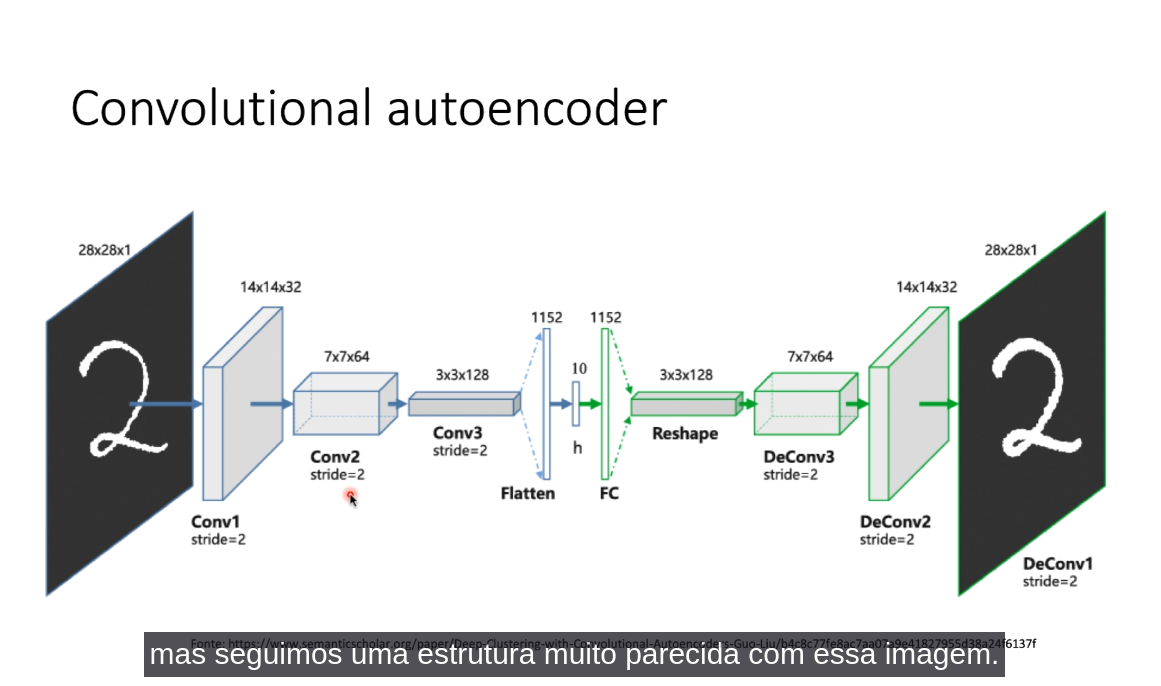


h armazena o resultado 

$\begin{array}{|c|c|c|c|}
\hline
\textbf{Função} & \textbf{Fórmula} & \textbf{Intervalo de saída} & \textbf{Uso comum} \\
\hline
\text{Sigmoid} & 
\sigma(x) = \frac{1}{1 + e^{-x}} & (0, 1) & \text{Classificação binária} \\
\hline
\text{Tanh} & 
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} & (-1, 1) & \text{Camadas ocultas (alternativa ao ReLU)} \\
\hline
\text{ReLU} & 
f(x) = \max(0, x) & [0, \infty) & \text{Camadas ocultas (mais usado)} \\
\hline
\text{Leaky ReLU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha x & \text{se } x \leq 0
\end{cases} & (-\infty, \infty) & \text{Evita neurônios mortos no ReLU} \\
\hline
\text{ELU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha(e^x - 1) & \text{se } x \leq 0
\end{cases} & (-\alpha, \infty) & \text{Camadas ocultas, alternativa ao ReLU} \\
\hline
\text{Softmax} & 
f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} & (0, 1), \ \sum f(x_i) = 1 & \text{Classificação multiclasse} \\
\hline
\end{array}$

# 🔹 O ReLU (Rectified Linear Unit)

Características:

Simples, rápido de calcular.

Resolve o problema do vanishing gradient (quando os gradientes ficam quase zero em sigmoides/tanh).

Muito usado em camadas ocultas.

⚠️ Problema: pode causar “neurônios mortos” (quando muitos valores ficam ≤ 0 e nunca mais reativam).


# 🔹 1. Sigmoid

Saída entre 0 e 1 → ideal para classificação binária.

Problema: saturação → gradientes muito pequenos para valores extremos.

# 🔹 2. Tanh (Tangente Hiperbólica)

Saída entre -1 e 1.

Centraliza os dados em torno de 0 (melhor que sigmoid).

Mas ainda sofre com vanishing gradient.

# 🔹 3. Leaky ReLU

Variante do ReLU que deixa um “vazamento” para valores negativos.

Resolve o problema de neurônios mortos.

#🔹 4. ELU (Exponential Linear Unit)

Parecido com ReLU, mas valores negativos seguem uma curva exponencial suave.
Melhora a aprendizagem, mas é mais caro computacionalmente.

#🔹 5. Softmax

Transforma um vetor de valores em probabilidades que somam 1.

Usado em classificação multiclasse (saída com várias categorias).



🔹 Resumo, o uso mais comum:

Camadas ocultas → ReLU, Leaky ReLU, às vezes Tanh/ELU.

Saída binária → Sigmoid.

Saída multiclasse → Softmax.



### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

In [11]:
# 1. torch.cuda.is_available(): Pergunta ao computador: "Ei, você tem uma placa de 
# vídeo da NVIDIA instalada e os drivers (CUDA) estão prontos para uso?"
# 
# 2. torch.device('cuda'): Se a resposta for SIM, o PyTorch reserva a GPU para 
# processar os cálculos. A GPU é centenas de vezes mais rápida para redes neurais.
# 
# 3. else torch.device('cpu'): Se a resposta for NÃO, ele usa o processador (CPU) 
# comum. O código vai funcionar, mas o treinamento será muito mais lento.
# 
# 4. device: Armazena essa decisão na variável para que você possa usar depois em 
# .to(device) para enviar seus modelos e dados para lá.
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Exibe qual foi a decisão (no Google Colab com GPU ativada, aparecerá 'cuda')
device

device(type='cpu')

In [13]:
# 1. model = autoencoder(): 
# Cria uma instância real do seu modelo. Nesse momento, o PyTorch:
# - Inicializa todos os filtros (kernels) das camadas Conv2d com valores aleatórios.
# - Reserva o espaço para as 11 camadas que definimos (enc, maxpool, dec, etc.).
model = autoencoder()

# 2. model.to(device):
# Pega toda essa estrutura de filtros e pesos e a transfere para o hardware escolhido.
# Se o seu device for 'cuda' (GPU), os cálculos serão feitos paralelamente em 
# milhares de núcleos, o que é essencial para camadas convolucionais.
model.to(device)

autoencoder(
  (enc0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (enc1): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2): Conv2d(8, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (maxpool0): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (maxpool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(1, 1), dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dec0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (dec3): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upsampling): UpsamplingBilinear2d(scale_factor=2.0, mode='bilinear')
  (activation0): ReLU()
  (activation1): Sigmoid()
)

In [14]:
# 1. DEFININDO O CRITÉRIO DE ERRO (Loss Function)
# nn.BCELoss() -> Binary Cross Entropy Loss (Entropia Cruzada Binária).
# Como sua última camada usa uma Sigmoid (pixels entre 0 e 1), o BCELoss
# vai comparar cada pixel da imagem original com o pixel da reconstruída.
# Ele pune severamente o modelo se ele disser que um pixel é 'preto' (0) 
# quando na verdade era 'branco' (1).
criterion = nn.BCELoss()

# 2. DEFININDO O OTIMIZADOR (O "Ajustador" de Pesos)
# optim.Adam -> É um dos algoritmos mais inteligentes para treinar Redes Neurais.
# model.parameters() -> Diz ao Adam para observar TODOS os filtros (kernels) 
# e pesos das camadas Conv2d que você definiu.
# O Adam decide o quanto cada peso deve mudar para que o 'criterion' (erro) 
# diminua na próxima tentativa.
optimizer = optim.Adam(model.parameters())

## Etapa 4: Treinamento do modelo

In [15]:
# Listas para guardar o histórico de erros
historico_loss_train = []
historico_loss_val = []


# O grande loop que fará o modelo "estudar" o dataset 20 vezes (épocas)
for epoch in range(20): # usamos 20 épocas, com estruturas mais complexas
    
    # Treinamento
    # --- FASE DE TREINAMENTO ---
    running_loss_train = 0.
    for data in loader_train:
        model.train() # Ativa o modo de aprendizado (ajusta pesos)
        
        # O Autoencoder é "Não Supervisionado": pegamos a imagem (inputs) 
        # e ignoramos a resposta certa (_), pois o alvo é a própria imagem.
        inputs, _ = data  # Descartando os rótulos porque não precisamos deles
        inputs = inputs.to(device)

        # 1. Zera a memória de erros anterior para não confundir o otimizador
        optimizer.zero_grad()

        # 2. Forward: Passa a imagem pela rede para ver o que ela reconstrói
        outputs = model(inputs)
        
        # 3. Cálculo do Erro: Compara a saída com a imagem original (o gabarito)
        # O .view(*outputs.shape) garante que a imagem original esteja no 
        # mesmo formato da saída para uma comparação justa.
        loss = criterion(outputs, inputs.view(*outputs.shape))
        
        # 4. Backward: A rede descobre "quem errou" em cada camada (backpropagation)
        loss.backward() # não precisa na validação

        # 5. Step: O Adam atualiza os filtros (kernels) para errar menos na próxima
        # atualiza os pesos
        optimizer.step() # não precisa na validação

        # Acumula o erro para calcularmos a média depois
        running_loss_train += loss.item()
        
    # Validação
    # --- FASE DE VALIDAÇÃO (O "Teste Surpresa") ---
    running_loss_val = 0.
    for data in loader_val:
        model.eval() # Modo de avaliação: apenas observa, NÃO altera os pesos
        with torch.no_grad(): # Desativa cálculos desnecessários para economizar memória
            inputs, _ = data
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs.view(*outputs.shape))
            running_loss_val += loss.item()
            
    # Final da época
    # --- RELATÓRIO DA ÉPOCA ---
    # Imprime o progresso para você monitorar se o erro está caindo.
    print('ÉPOCA {:3d}: perda_train {:.5f} perda_val {:.5f}'.format(
        epoch + 1, 
        running_loss_train/len(loader_train), 
        running_loss_val/len(loader_val)
    ))
    # Salva as médias da época nas listas
    historico_loss_train.append(running_loss_train/len(loader_train))
    historico_loss_val.append(running_loss_val/len(loader_val))

    

ÉPOCA   1: perda_train 0.33561 perda_val 0.21530
ÉPOCA   2: perda_train 0.19832 perda_val 0.18150
ÉPOCA   3: perda_train 0.17400 perda_val 0.16659
ÉPOCA   4: perda_train 0.16368 perda_val 0.15967
ÉPOCA   5: perda_train 0.15844 perda_val 0.15452
ÉPOCA   6: perda_train 0.15416 perda_val 0.15228
ÉPOCA   7: perda_train 0.15040 perda_val 0.14758
ÉPOCA   8: perda_train 0.14725 perda_val 0.14509
ÉPOCA   9: perda_train 0.14460 perda_val 0.14133
ÉPOCA  10: perda_train 0.14233 perda_val 0.14005
ÉPOCA  11: perda_train 0.13951 perda_val 0.13673
ÉPOCA  12: perda_train 0.13706 perda_val 0.13513
ÉPOCA  13: perda_train 0.13506 perda_val 0.13274
ÉPOCA  14: perda_train 0.13336 perda_val 0.13160
ÉPOCA  15: perda_train 0.13182 perda_val 0.12982
ÉPOCA  16: perda_train 0.13047 perda_val 0.12854
ÉPOCA  17: perda_train 0.12913 perda_val 0.12702
ÉPOCA  18: perda_train 0.12815 perda_val 0.12649
ÉPOCA  19: perda_train 0.12680 perda_val 0.12593
ÉPOCA  20: perda_train 0.12602 perda_val 0.12372


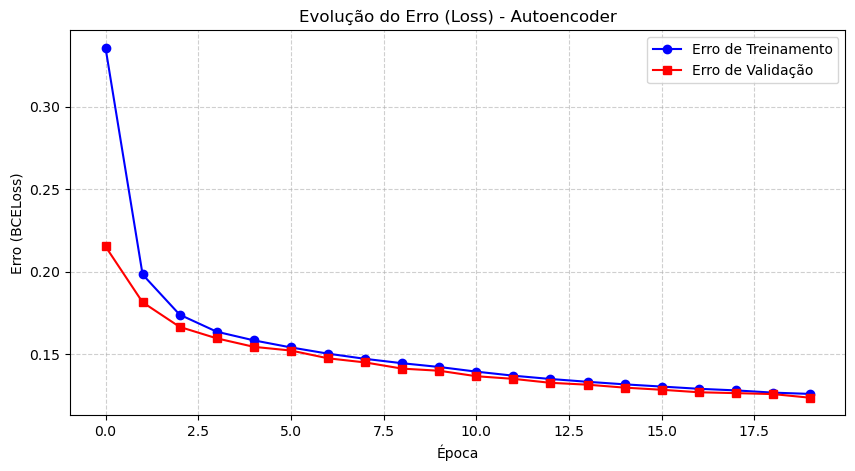

In [17]:
import matplotlib.pyplot as plt

# Configura o tamanho e o estilo do gráfico
plt.figure(figsize=(10, 5))
plt.plot(historico_loss_train, label='Erro de Treinamento', color='blue', marker='o')
plt.plot(historico_loss_val, label='Erro de Validação', color='red', marker='s')

# Detalhes visuais
plt.title('Evolução do Erro (Loss) - Autoencoder')
plt.xlabel('Época')
plt.ylabel('Erro (BCELoss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Exibe o gráfico
plt.show()

🔍 O que observar no gráfico?

Curvas Descendo: Se ambas as linhas estão caindo e se aproximando do zero, seu Autoencoder está aprendendo a reconstruir as imagens com perfeição.

A "Diferença" (Gap): Se a linha azul (treino) continuar descendo muito e a vermelha (validação) começar a subir ou estabilizar, seu modelo está "decorando" (overfitting).

Estabilidade: Se as curvas ficarem "flat" (planas) antes da época 20, significa que o modelo já aprendeu tudo o que podia e você não precisaria de mais épocas.

## Etapa 5: Geração do encoder

In [16]:
# percorrer as camadas
for i, layer in enumerate(list(model.children())):
    print(i, layer)

0 Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
1 Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
2 Conv2d(8, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
3 MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
4 MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(1, 1), dilation=1, ceil_mode=False)
5 Flatten(start_dim=1, end_dim=-1)
6 Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
7 Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
8 Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
9 Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
10 UpsamplingBilinear2d(scale_factor=2.0, mode='bilinear')
11 ReLU()
12 Sigmoid()


In [18]:
# construir o gerador

In [19]:
class encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc0 = list(model.children())[0]
        self.enc1 = list(model.children())[1]
        self.enc2 = list(model.children())[2]

        self.maxpool0 = list(model.children())[3]
        self.maxpool1 = list(model.children())[4]

        self.flatten = list(model.children())[5] # transformar em vetor (com a codificação)

        self.activation0 = list(model.children())[11] # camada RELU

    def forward(self, X):
        # fazemos as ligações
        # recebe a imagem e faz todo o processamento. Retornar a imagem com as dimensões reduzidas.
        X = self.maxpool0(self.activation0(self.enc0(X)))
        X = self.maxpool1(self.activation0(self.enc1(X)))
        X = self.flatten(self.activation0(self.enc2(X)))

        return X

In [20]:
# criamos o codificador, com o modelo 1
model1 = encoder()
model1.to(device)  # mandamos para o dispositivo, com o Flatten

encoder(
  (enc0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (enc1): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2): Conv2d(8, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (maxpool0): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (maxpool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(1, 1), dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (activation0): ReLU()
)

## Etapa 6: Geração do decoder

In [21]:
for i, layer in enumerate(list(model.children())):
    print(i, layer)

0 Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
1 Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
2 Conv2d(8, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
3 MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
4 MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(1, 1), dilation=1, ceil_mode=False)
5 Flatten(start_dim=1, end_dim=-1)
6 Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
7 Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
8 Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
9 Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
10 UpsamplingBilinear2d(scale_factor=2.0, mode='bilinear')
11 ReLU()
12 Sigmoid()


In [22]:
class decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.dec0 = list(model.children())[6]
        self.dec1 = list(model.children())[7]
        self.dec2 = list(model.children())[8]
        self.dec3 = list(model.children())[9]

        self.upsampling = list(model.children())[10]

        self.activation0 = list(model.children())[11]
        self.activation1 = list(model.children())[12] # retorna a resposta fina, sigmoid

    def forward(self, X):
        # ligação entre as camadas, da decodificação, processo inverso
        X = X.view(-1, 8, 4, 4) # mostrar as dimensões corretas
        X = self.upsampling(self.activation0(self.dec0(X)))
        X = self.upsampling(self.activation0(self.dec1(X)))
        X = self.upsampling(self.activation0(self.dec2(X)))
        X = self.activation1(self.dec3(X))

        return X

In [23]:
# criamos o modelo 2, para mandarmos ao dispositivo
model2 = decoder()
model2.to(device)

decoder(
  (dec0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (dec3): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upsampling): UpsamplingBilinear2d(scale_factor=2.0, mode='bilinear')
  (activation0): ReLU()
  (activation1): Sigmoid()
)

## Etapa 7: Visualização dos resultados

In [24]:
numero_imagens = 10
# pegarmos 10 imagens no teste e mandamos para o disositivo (device)
imagens_teste = next(iter(loader_val))[0][:numero_imagens]
imagens_teste = imagens_teste.to(device)

In [25]:

# visualizar o shape
# 10 imagens, 1 número de canais, altura e lagura com 28
imagens_teste.shape

torch.Size([10, 1, 28, 28])

In [26]:
# Imagens codificadas
model1.eval()
imagens_codificadas = model1(imagens_teste)

In [40]:
16 * 8

128

In [27]:
imagens_codificadas.shape

torch.Size([10, 128])

In [36]:
# 10 imagens com 128 pixels, na camada flatten 128, convertido para um vetor.

In [37]:
# Imagens decodificadas
model2.eval()
imagens_decodificadas = model2(imagens_codificadas)

In [39]:
imagens_decodificadas.shape # voltnado a dimensionalidade original

torch.Size([10, 1, 28, 28])

In [41]:
# visualizar a imagem

In [43]:
16 * 8 # meio, verto para converter na dimensionalidade, no formato de matriz para mostrar a imagem

128

In [44]:
# Formatando as imagens para visualização
imagens_teste = imagens_teste.detach().cpu().numpy().reshape(-1, 28, 28)
imagens_codificadas = imagens_codificadas.detach().cpu().numpy().reshape(-1, 16, 8) # 16 pixels altura e 8 pixels de largura
# 16*8 = 128
imagens_decodificadas = imagens_decodificadas.detach().cpu().numpy().reshape(-1, 28, 28)

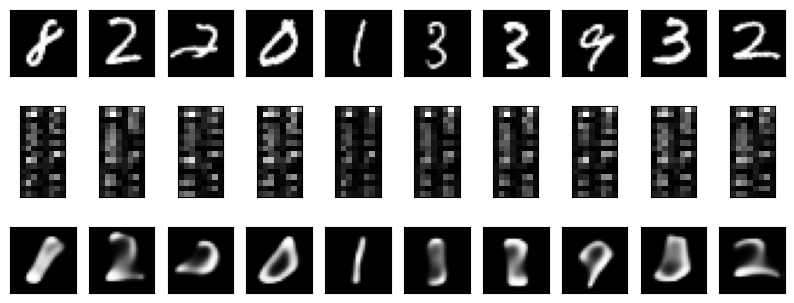

In [45]:
# imagem codificada
fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for imagens, ax_row in zip([imagens_teste, imagens_codificadas, imagens_decodificadas], axes):
    for img, ax in zip(imagens, ax_row):
        ax.imshow(img, cmap = 'gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

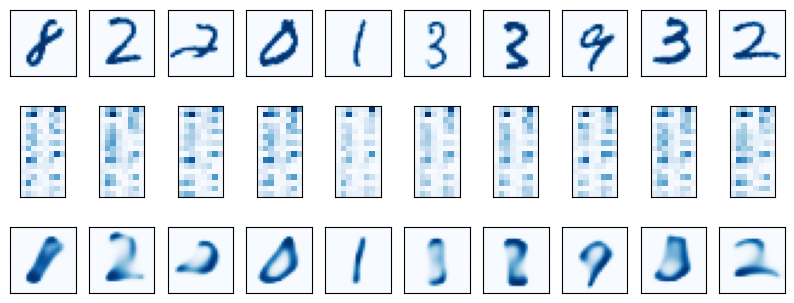

In [46]:
# imagem codificada
fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for imagens, ax_row in zip([imagens_teste, imagens_codificadas, imagens_decodificadas], axes):
    for img, ax in zip(imagens, ax_row):
        ax.imshow(img, cmap = 'Blues')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

In [47]:
# compelxidade convulocional é maior, teria que colocar mais épocas, 

# autoencoders convolutional é melhor, tem maior desempenho